### Module Imports

In [1]:
import json
from collections import namedtuple, Counter

import numpy as np
import scanpy as sc
import pandas as pd

## Image manipulation and geometry
from tifffile import imread
from skimage.io import imread as skimread

## Plotting imports
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_hex, Colormap
from matplotlib.cm import ScalarMappable

### Functions for registration of Xenium to Visium data and associated analyis and visualization
## Visualization functions
from companion_functions import (
    hexlist_to_cmap,
    polygons_coords_to_patch_collection,
    plot_polygons,
    hex_corner_offset,
    polygon_corners,
    celltypes,
    celltypes,
    hex_codes,
    ctype_to_code_map,
    ctype_hex_map,
    ctype_cmap,
)

## Analysis functions
from companion_functions import (
    unique_encode,
    get_xenium_to_morphology_transform_from_xenium_morphology_image,
    get_xenium_capture_polygon_um,
    transform_coordinates,
    get_median_spot_to_spot_distance_from_centroids,
    generate_space_filling_visium_polygons,
    get_visium_capture_polygon,
    __OUTSIDE_VISIUM_CAPTURE_AREA_BARCODE__,
    bin_xenium_data_to_visium_spots,
    generate_anndata_matrix_from_transcript_assignments,
)

In [2]:
## Load Visium spot X gene matrix
visium_adata = sc.read_10x_h5("../../../../../data/10X_Xenium_Visium/Visium/CytAssist_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5")

## Load Visium spot position information
visium_tissue_positions = (
    pd.read_csv("../../../../../data/10X_Xenium_Visium/Visium/spatial/tissue_positions.csv")
    .set_index("barcode")
    .reindex(visium_adata.obs.index)
)

## Load Visium scale metadata
## Contains scalefactors to transform between Visium full resolution and the high resolution images.
with open("../../../../../data/10X_Xenium_Visium/Visium/spatial/scalefactors_json.json") as file:
    visium_scale_factors = json.load(file)

## Load the Visium high resolution H&E for plotting
visium_high_res_image = skimread(
    "../../../../../data/10X_Xenium_Visium/Visium/spatial/tissue_hires_image.png"
)

/Users/amanuky/miniforge3/envs/xenium-publication-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/amanuky/miniforge3/envs/xenium-publication-env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
## Read in the Xenium cell positions and cell metadata.
path_to_xenium_bundle = "../../../../../data/10X_Xenium_Visium/Xenium_R1/outs/"
xenium_cell_info = pd.read_csv(path_to_xenium_bundle + "cells.csv.gz").set_index(
    "cell_id"
)

## Read in the Xenium morphology (DAPI) MIP image. Note: We are reading the image at the resolution of
## the third pyramid level: full_resolution / 2 ** 3. We are using this image for plotting.
## The Xenium imaging area is large, and the full resolution image is large enough to be slow to plot.
## Working with a lower resolution image when possible is a convenience.
pyramid_level = 3
xenium_morphology_mip_at_pyramid_level = imread(
    path_to_xenium_bundle + "morphology_mip.ome.tif", series=0, level=pyramid_level
)

## Transformation matrix to transform from the Xenium coordinate system to the morphology image coordinate system
## at pyramid level. Determined using the pixel size of the morphology image. 
xenium_to_morphology_at_pyramid_transformation = (
    get_xenium_to_morphology_transform_from_xenium_morphology_image(
        path_to_xenium_bundle + "morphology_mip.ome.tif", pyramid_level
    )
)

In [4]:
## Transformation matrix exported from Xenium Explorer
xenium_morphology_to_visium_full_res_transformation = np.array(
    [
        [1.87594468e-02, -4.07641677e-01, 1.63476055e04],
        [3.91300071e-01, 1.26819551e-02, 4.12499099e03],
        [-8.39854141e-08, -9.91112632e-07, 1.03706895e00],
    ]
)

## Transformation matrix between Xenium full resolution (DAPI) morphology image and the Xenium coordinate system.
xenium_to_morphology_transformation = (
    get_xenium_to_morphology_transform_from_xenium_morphology_image(
        path_to_xenium_bundle + "morphology_mip.ome.tif", 0
    )
)

## Xenium coordinates must be transformed into image coordinates before being transformed into Visium image coordinates.
## The following describes that combined transformation (a matrix multiplication of the two transformation matrices).
xenium_to_visium_full_res_transformation = (
    xenium_morphology_to_visium_full_res_transformation
    @ xenium_to_morphology_transformation
)

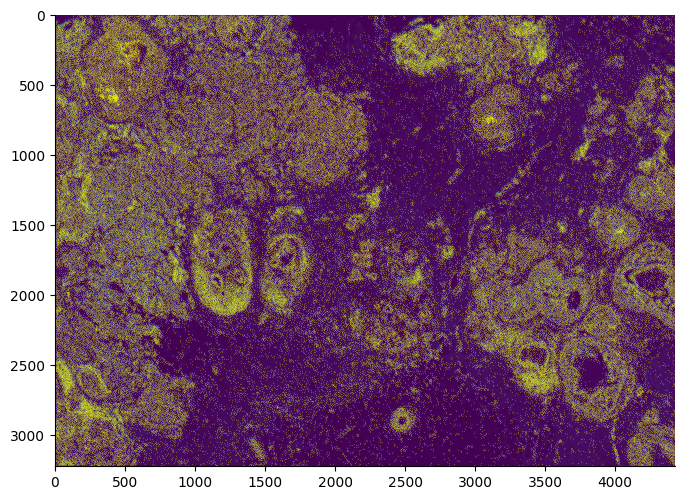

In [5]:
## data setup
## get Xenium coordinates -> transformed into Xenium morphology pixel coordinates
coords = transform_coordinates(
    xenium_cell_info[["x_centroid", "y_centroid"]].values,
    xenium_to_morphology_at_pyramid_transformation,
)

## plot style setup
fig = plt.figure(figsize=(8, 8))
ax = plt.gca()

## plotting code
ax.imshow(xenium_morphology_mip_at_pyramid_level)
ax.scatter(*coords.T, s=0.1, linewidth=0, edgecolor=None, marker="o", color="yellow")

## plot style adjustments
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
ax.set_aspect("equal", adjustable="box")

#### Figure demonstrating the Xenium/Visium registration

The Visium H&E high resolution image is displayed with Xenium cell coordinates transformed and overlaid in gold. For demonstration, the Xenium morphology image bounding polygon is displayed in blue.

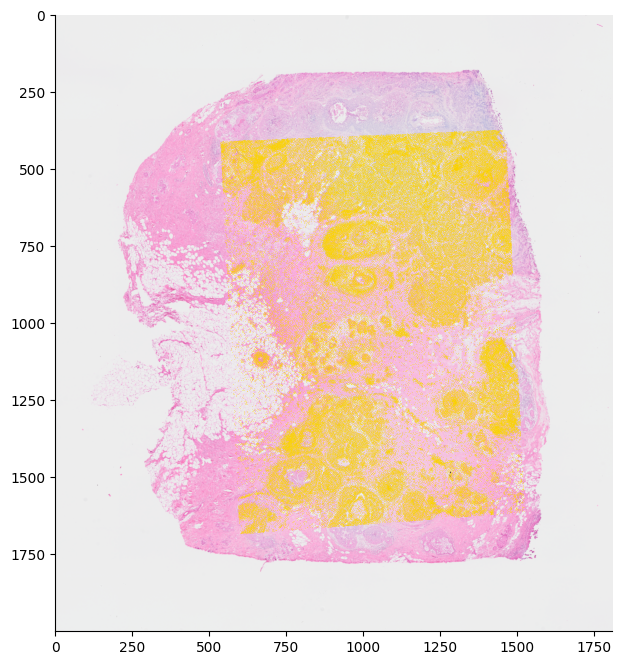

In [7]:
## data setup
## Xenium cell coordinates are transformed first into Visium full resolution image coordinates,
## and then scaled to high resolution image coordinates.
xenium_cell_centroids_visium_high_res = (
    transform_coordinates(
        xenium_cell_info[["x_centroid", "y_centroid"]].values,
        xenium_to_visium_full_res_transformation,
    )
    * visium_scale_factors["tissue_hires_scalef"]
)

## The Xenium capture polygon is obtained and similarly transformed.
xenium_capture_polygon_um = get_xenium_capture_polygon_um(path_to_xenium_bundle)
xenium_capture_polygon_visium_high_res = (
    transform_coordinates(
        xenium_capture_polygon_um, xenium_to_visium_full_res_transformation
    )
    * visium_scale_factors["tissue_hires_scalef"]
)

## plot style setup
fig = plt.figure(figsize=(8, 8))
ax = plt.gca()

## plotting code
ax.imshow(visium_high_res_image)
ax.scatter(
    *xenium_cell_centroids_visium_high_res.T,
    s=0.1,
    linewidth=0,
    edgecolor=None,
    marker="o",
    color="gold"
)

## plot style adjustments
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
ax.set_aspect("equal", adjustable="box")

In [9]:
import pandas as pd 
df = pd.DataFrame(xenium_cell_centroids_visium_high_res)
df.to_csv("results/xenium_cell_centroids_visium_high_res.csv")